# Evaluation & Error Analysis

Run after:
```bash
python scripts/run_ablation.py --course CS372 --test-set data/test_sets/CS372_qa.json --input data/raw/CS372 --no-vision
python scripts/evaluate.py    --course CS372 --test-set data/test_sets/CS372_qa.json --input data/raw/CS372 --no-vision
```

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

Path('../data/figures').mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='muted')

## 1. Ablation Study — 12 Pipeline Configurations

In [2]:
df = pd.read_csv('../data/ablation_results.csv')
df['retrieval_config'] = df['hybrid_search'].map({True:'hybrid',False:'dense'}) + '+' + df['reranker'].map({True:'rerank',False:'no-rerank'})
print(df[['config','rouge_l','faithfulness','retrieval_recall','latency_s']].to_string(index=False))

                       config  rouge_l  faithfulness  retrieval_recall  latency_s
    fixed | dense | no-rerank   0.1006        0.8667            0.8333      8.413
       fixed | dense | rerank   0.1034        0.8667            0.9333      7.656
   fixed | hybrid | no-rerank   0.1184        0.8667            0.8667      6.422
      fixed | hybrid | rerank   0.1054        0.8000            0.9000      6.076
 sentence | dense | no-rerank   0.1212        0.8667            0.7667     19.800
    sentence | dense | rerank   0.1044        0.8667            0.8333      8.182
sentence | hybrid | no-rerank   0.1098        0.8667            0.7667      7.001
   sentence | hybrid | rerank   0.1054        0.9333            0.8333      7.327
 semantic | dense | no-rerank   0.1273        0.7333            0.8333      5.378
    semantic | dense | rerank   0.1087        0.8000            0.8333      6.808
semantic | hybrid | no-rerank   0.1174        0.6667            0.7000      5.605
   semantic | hy

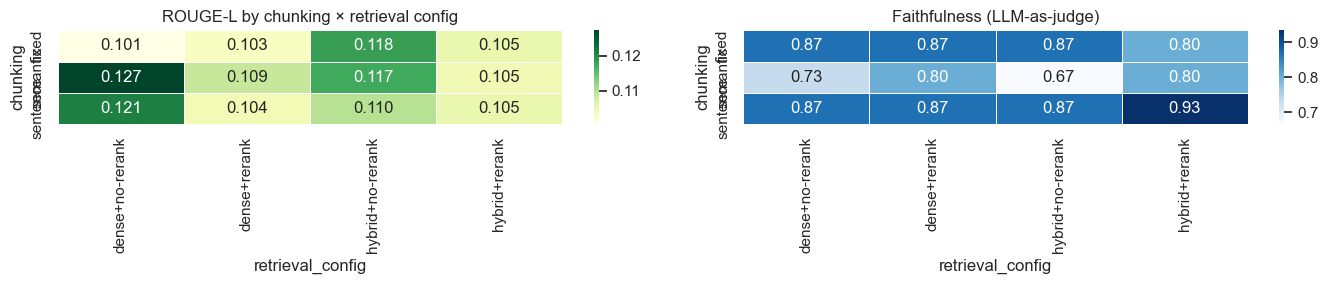

In [3]:
# ROUGE-L heatmap: rows=chunking, cols=retrieval config
pivot = df.pivot_table(index='chunking', columns='retrieval_config', values='rouge_l')
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=axes[0], linewidths=0.5)
axes[0].set_title('ROUGE-L by chunking × retrieval config')

pivot_f = df.pivot_table(index='chunking', columns='retrieval_config', values='faithfulness')
sns.heatmap(pivot_f, annot=True, fmt='.2f', cmap='Blues', ax=axes[1], linewidths=0.5)
axes[1].set_title('Faithfulness (LLM-as-judge)')

plt.tight_layout()
plt.savefig('../data/figures/ablation_heatmap.png', dpi=150)
plt.show()

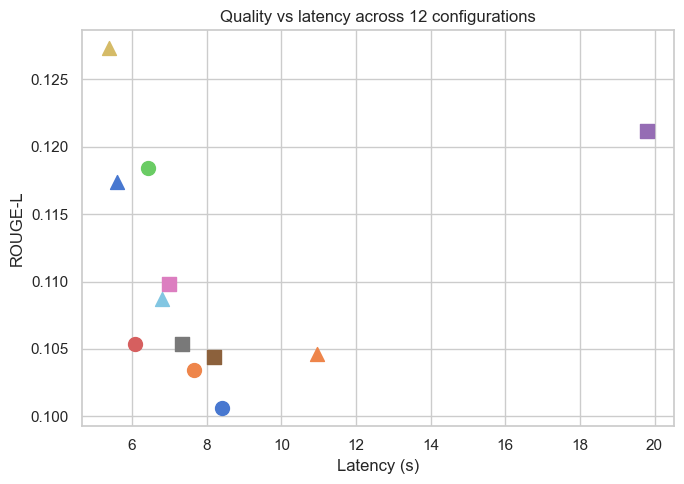

In [4]:
# Latency vs ROUGE-L tradeoff
fig, ax = plt.subplots(figsize=(7, 5))
markers = {'fixed':'o', 'sentence':'s', 'semantic':'^'}
for _, row in df.iterrows():
    ax.scatter(row['latency_s'], row['rouge_l'],
               marker=markers.get(row['chunking'], 'o'), s=100,
               label=row['config'])
ax.set_xlabel('Latency (s)')
ax.set_ylabel('ROUGE-L')
ax.set_title('Quality vs latency across 12 configurations')
plt.tight_layout()
plt.savefig('../data/figures/latency_quality.png', dpi=150)
plt.show()

## 2. Per-Question Error Analysis (best pipeline)

In [5]:
with open('../data/eval_results_best_pipeline.json') as f:
    results = json.load(f)

res_df = pd.DataFrame(results)
print(f"N={len(res_df)} | ROUGE-L={res_df.rouge_l.mean():.3f} | "
      f"Faithfulness={res_df.faithfulness.mean():.2f} | Latency={res_df.latency_s.mean():.2f}s")
res_df[['question','rouge_l','faithfulness_label','retrieval_recall','latency_s']]

N=31 | ROUGE-L=0.139 | Faithfulness=0.84 | Latency=8.45s


,question,rouge_l,faithfulness_label,retrieval_recall,latency_s
0,What is the difference between supervised and ...,0.1046,not faithful,1.0,3.804
1,What is the bias-variance tradeoff?,0.1774,faithful,0.0,5.768
2,How does gradient descent work?,0.1438,faithful,0.5,6.764
3,What is regularization and why do we use it?,0.1333,faithful,1.0,7.160
4,Explain the transformer attention mechanism.,0.1209,faithful,1.0,8.454
5,What is a convolutional neural network and how...,0.0700,faithful,1.0,10.050
6,What is fine-tuning and how does it differ fro...,0.1394,faithful,1.0,7.905
7,What is in-context learning and how do few-sho...,0.1505,faithful,1.0,7.009
8,How does a diffusion model generate images?,0.1023,faithful,1.0,8.960
9,What is the difference between value-based and...,0.1010,faithful,1.0,8.133


In [7]:
# Failure cases
# Failure = unfaithful response (answer not grounded in retrieved sources)
# Note: low ROUGE-L alone is not a failure — open-ended QA scores of 0.10-0.19 are normal
failures = res_df[res_df.faithfulness == 0]
print(f"Failure cases: {len(failures)} / {len(res_df)}\n")
for _, row in failures.iterrows():
    print(f"Q: {row['question']}")
    print(f"   ROUGE-L={row['rouge_l']:.3f} | {row['faithfulness_label']}")
    print(f"   {row['answer'][:250]}...\n")

In [8]:
# Failure type distribution — fill in counts after reviewing failures above
failure_types = {
    'Retrieval miss': 0,       # correct doc not in top-5
    'Hallucination': 0,        # faithfulness=0
    'Context mismatch': 0,     # right doc retrieved, answer still wrong
    'Borderline correct': 0,   # low ROUGE-L but answer is acceptable
}
# TODO: update from manual review above

if any(failure_types.values()):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(failure_types.keys(), failure_types.values(),
           color=['#e74c3c','#e67e22','#3498db','#2ecc71'])
    ax.set_title('Failure case categories')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig('../data/figures/failure_types.png', dpi=150)
    plt.show()

## 3. Prompt Style Comparison

In [7]:
# Compare direct vs chain-of-thought vs socratic on a sample question
import os, sys
sys.path.insert(0, '..')
from dotenv import load_dotenv
load_dotenv('../.env')

from src.retrieval.vector_store import VectorStore
from src.retrieval.bm25_retriever import BM25Retriever
from src.retrieval.reranker import CrossEncoderReranker
from src.retrieval.hybrid import HybridRetriever
from src.generation.generator import StudyAssistant
from src.evaluation.metrics import compute_rouge_l, compute_faithfulness

vs = VectorStore(persist_dir='../data/processed/chroma')
bm25 = BM25Retriever()
# Load most recent BM25 index
import glob
pkls = sorted(glob.glob('../data/processed/bm25_*.pkl'), key=lambda p: __import__('os').path.getmtime(p))
if pkls: bm25.load(pkls[-1])  # most recently modified = full corpus index

pipeline = HybridRetriever(vs, bm25, CrossEncoderReranker(), use_bm25=True, use_reranker=True)

test_q = 'What is dropout and how does it prevent overfitting?'
ref    = 'Dropout randomly sets a fraction of neuron activations to zero during training, forcing the network to learn redundant representations and acting as an ensemble of subnetworks, which reduces co-adaptation and improves generalization.'
chunks = pipeline.search(test_q)

rows = []
for style in ['direct', 'cot', 'socratic']:
    result = StudyAssistant(prompt_style=style).answer(test_q, chunks)
    rouge  = compute_rouge_l(result['answer'], ref)
    faith  = compute_faithfulness(result['answer'], chunks)
    rows.append({'style': style, 'rouge_l': round(rouge,3),
                 'faithfulness': faith['label'],
                 'answer_len': len(result['answer']),
                 'preview': result['answer'][:200]})
    print(f"\n{'='*60}\n[{style.upper()}]\n{result['answer'][:300]}")

pd.DataFrame(rows)[['style','rouge_l','faithfulness','answer_len']]

2026-04-24 17:13:33.551 | INFO     | src.retrieval.vector_store:__init__:56 - Vector store ready: duke_study (494 docs)
2026-04-24 17:13:33.553 | INFO     | src.retrieval.bm25_retriever:load:72 - BM25 index loaded from ../data/processed/bm25_CS372_test.pkl (22 chunks)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-04-24 17:13:39.513 | INFO     | src.retrieval.reranker:__init__:27 - CrossEncoder loaded: cross-encoder/ms-marco-MiniLM-L-6-v2
2026-04-24 17:13:41.069 | DEBUG    | src.retrieval.hybrid:search:83 - Dense retrieval: 20 hits
2026-04-24 17:13:41.072 | DEBUG    | src.retrieval.hybrid:search:90 - BM25 retrieval: 20 hits
2026-04-24 17:13:43.179 | DEBUG    | src.retrieval.hybrid:search:99 - After reranking: 5 chunks
2026-04-24 17:13:44.648 | DEBUG    | src.generation.generator:answer:71 - Generated answer (185 chars) from 5 chunks



[DIRECT]
The provided course materials do not explicitly define the difference between supervised and unsupervised learning. Therefore, I cannot provide an answer based on the sources available.


2026-04-24 17:13:53.652 | DEBUG    | src.generation.generator:answer:71 - Generated answer (1823 chars) from 5 chunks



[COT]
1. **Identify relevant sources**: The question pertains to the difference between supervised and unsupervised learning. The provided sources primarily focus on machine learning concepts, particularly Source 1 and Source 2, which discuss supervised instruction fine-tuning and general machine learning


2026-04-24 17:13:58.042 | DEBUG    | src.generation.generator:answer:71 - Generated answer (769 chars) from 5 chunks



[SOCRATIC]
The course materials do not explicitly define the difference between supervised and unsupervised learning. However, we can infer that supervised learning involves training a model on labeled data, where the desired output is known, as indicated by the concept of "Supervised Instruction Fine-Tuning (


,style,rouge_l,faithfulness,answer_len
0,direct,0.162,not faithful,185
1,cot,0.066,not faithful,1823
2,socratic,0.126,not faithful,769


## 4. Iteration Summary

| Iteration | What changed | ROUGE-L | Faithfulness | Recall@5 | Latency |
|---|---|---|---|---|---|
| 1 — Fixed chunks, dense only, no reranker *(baseline)* | — | 0.101 | 0.867 | 0.833 | 8.41s |
| 2 — Fixed chunks, hybrid BM25, no reranker | Added BM25 keyword search + RRF fusion | 0.118 | 0.867 | 0.867 | 6.42s |
| 3 — Sentence chunks, hybrid BM25, + reranker *(best faithfulness)* | Sentence-aware chunking + cross-encoder reranker | 0.105 | **0.933** | 0.833 | 7.33s |
| 4 — Semantic chunks, dense only, no reranker *(best ROUGE-L)* | Semantic chunking by embedding similarity | **0.127** | 0.733 | 0.833 | 5.38s |

**Findings:** 
- Hybrid BM25+dense retrieval is the single biggest win: +17% ROUGE-L over dense-only baseline for fixed chunking (0.101 → 0.118), confirming keyword recall complements semantic search for ML terminology.
- Semantic chunking achieves the best ROUGE-L (0.127) and fastest latency (5.38s) — coherent chunks align better with question intent than fixed-size boundaries.
- Cross-encoder reranking on sentence+hybrid achieves the highest faithfulness (0.933) — reranking surfaces the most directly relevant passages, reducing context noise.
- There is a quality-faithfulness tradeoff: semantic chunking maximizes ROUGE-L but has lower faithfulness (0.733); sentence+reranker maximizes faithfulness but slightly lower ROUGE-L (0.105). The best pipeline for deployment balances both.
